In [1]:
import os
import glob
import numpy as np
import torch
import torch.utils.data
from PIL import Image
import cv2

from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

In [2]:
import numpy as np
import random
import tensorflow as tf
import requests, pickle

def set_seed(seed_value=12345):
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)

### **Data Preprocessing**

In [25]:
import cv2

img = cv2.imread("content/sipakmed-dataset/im_Dyskeratotic/002.bmp")

print(img.shape)  # (height, width, channels)

(1536, 2048, 3)


In [ ]:
import os
import shutil
import cv2
from glob import glob

# =========================
# CONFIG
# =========================

DATASET_ROOT = "content/sipakmed-dataset"
OUTPUT_ROOT = "content/dataset_split"

CLASSES = [
    "im_Dyskeratotic",
    "im_Koilocytotic",
    "im_Metaplastic",
    "im_Parabasal",
    "im_Superficial-Intermediate"
]


IMG_SIZE = 1024

SYSTEM_TEST_RATIO = 0.15
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


# =========================
# CREATE OUTPUT STRUCTURE
# =========================

splits = ["train", "val", "test", "system_test"]

for split in splits:
    os.makedirs(f"{OUTPUT_ROOT}/{split}/images", exist_ok=True)
    os.makedirs(f"{OUTPUT_ROOT}/{split}/labels", exist_ok=True)

In [ ]:
# =========================
# READ POLYGON (.dat)
# =========================

def read_polygon(dat_path):

    pts = []

    with open(dat_path) as f:
        for line in f:

            line = line.strip()

            if not line:
                continue

            parts = line.split(",")

            if len(parts) != 2:
                continue

            try:
                x = float(parts[0])
                y = float(parts[1])
                pts.append([x, y])
            except:
                continue

    return np.array(pts)



# =========================
# POLYGON → BBOX
# =========================

def polygon_to_bbox(polygon):

    x_min = np.min(polygon[:,0])
    y_min = np.min(polygon[:,1])

    x_max = np.max(polygon[:,0])
    y_max = np.max(polygon[:,1])

    return [x_min, y_min, x_max, y_max]


# =========================
# LETTERBOX RESIZE
# =========================

def letterbox(image, bboxes):

    h, w = image.shape[:2]

    scale = min(IMG_SIZE / w, IMG_SIZE / h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(image, (new_w, new_h))

    canvas = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    pad_x = (IMG_SIZE - new_w) // 2
    pad_y = (IMG_SIZE - new_h) // 2

    canvas[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized

    new_boxes = []

    for box in bboxes:

        x1,y1,x2,y2 = box

        x1 = x1*scale + pad_x
        x2 = x2*scale + pad_x
        y1 = y1*scale + pad_y
        y2 = y2*scale + pad_y

        new_boxes.append([x1,y1,x2,y2])

    return canvas, new_boxes


# =========================
# BBOX → YOLO FORMAT
# =========================

def bbox_to_yolo(box, img_size):

    x1,y1,x2,y2 = box

    cx = (x1 + x2) / 2 / img_size
    cy = (y1 + y2) / 2 / img_size

    w = (x2 - x1) / img_size
    h = (y2 - y1) / img_size

    return cx,cy,w,h


# =========================
# COLLECT IMAGES
# =========================

data = []

for cls_id, cls in enumerate(CLASSES):

    images = glob(f"{DATASET_ROOT}/{cls}/*.bmp")

    for img in images:

        data.append((img, cls_id))


# =========================
# SPLIT DATASET
# =========================

random.shuffle(data)

n = len(data)

system_test_n = int(n * SYSTEM_TEST_RATIO)

system_test = data[:system_test_n]

remain = data[system_test_n:]

train_n = int(len(remain) * TRAIN_RATIO)
val_n = int(len(remain) * VAL_RATIO)

train = remain[:train_n]
val = remain[train_n:train_n+val_n]
test = remain[train_n+val_n:]


splitted = {
    "train":train,
    "val":val,
    "test":test,
    "system_test":system_test
}


# =========================
# PRINT CLASS COUNT
# =========================

print("\nDataset distribution")

for split in splitted:

    counts = {c:0 for c in CLASSES}

    for img,cls in splitted[split]:

        counts[CLASSES[cls]] += 1

    print("\n",split)

    for k,v in counts.items():
        print(k,v)


# =========================
# PROCESS DATA
# =========================

for split in splitted:

    for img_path, cls_id in splitted[split]:

        img = cv2.imread(img_path)

        base = os.path.basename(img_path).replace(".bmp","")

        folder = os.path.dirname(img_path)

        cyt_files = glob(f"{folder}/{base}_cyt*.dat")

        boxes = []

        for dat in cyt_files:

            polygon = read_polygon(dat)

            box = polygon_to_bbox(polygon)

            boxes.append(box)

        img, boxes = letterbox(img, boxes)

        save_img = f"{OUTPUT_ROOT}/{split}/images/{base}.jpg"

        cv2.imwrite(save_img, img)

        label_path = f"{OUTPUT_ROOT}/{split}/labels/{base}.txt"

        with open(label_path,"w") as f:

            for box in boxes:

                cx,cy,w,h = bbox_to_yolo(box, IMG_SIZE)

                f.write(f"{cls_id} {cx} {cy} {w} {h}\n")


Dataset distribution

 train
im_Dyskeratotic 132
im_Koilocytotic 135
im_Metaplastic 167
im_Parabasal 64
im_Superficial-Intermediate 77

 val
im_Dyskeratotic 27
im_Koilocytotic 36
im_Metaplastic 28
im_Parabasal 13
im_Superficial-Intermediate 19

 test
im_Dyskeratotic 28
im_Koilocytotic 33
im_Metaplastic 35
im_Parabasal 13
im_Superficial-Intermediate 15

 system_test
im_Dyskeratotic 36
im_Koilocytotic 34
im_Metaplastic 41
im_Parabasal 18
im_Superficial-Intermediate 15


#### Data Augmentation

In [16]:
import os
import cv2

TRAINSET_ROOT = "content/dataset_split/train"

IMG_DIR = os.path.join(TRAINSET_ROOT, "images")
LABEL_DIR = os.path.join(TRAINSET_ROOT, "labels")


# =========================
# READ YOLO LABEL
# =========================

def read_yolo_label(path):

    boxes = []

    with open(path) as f:
        for line in f:

            cls, cx, cy, w, h = line.strip().split()

            boxes.append([
                int(cls),
                float(cx),
                float(cy),
                float(w),
                float(h)
            ])

    return boxes


# =========================
# WRITE YOLO LABEL
# =========================

def write_yolo_label(path, boxes):

    with open(path, "w") as f:

        for cls,cx,cy,w,h in boxes:

            f.write(f"{cls} {cx} {cy} {w} {h}\n")


# =========================
# HORIZONTAL FLIP
# =========================

def flip_horizontal(boxes):

    new_boxes = []

    for cls,cx,cy,w,h in boxes:

        cx = 1 - cx

        new_boxes.append([cls,cx,cy,w,h])

    return new_boxes


# =========================
# VERTICAL FLIP
# =========================

def flip_vertical(boxes):

    new_boxes = []

    for cls,cx,cy,w,h in boxes:

        cy = 1 - cy

        new_boxes.append([cls,cx,cy,w,h])

    return new_boxes


# =========================
# AUGMENT DATASET
# =========================

images = os.listdir(IMG_DIR)

for img_name in images:

    img_path = os.path.join(IMG_DIR, img_name)

    base = img_name.replace(".jpg","")

    label_path = os.path.join(LABEL_DIR, base + ".txt")

    if not os.path.exists(label_path):
        continue

    img = cv2.imread(img_path)

    boxes = read_yolo_label(label_path)


    # ---------------------
    # Horizontal Flip
    # ---------------------

    img_h = cv2.flip(img, 1)

    boxes_h = flip_horizontal(boxes)

    new_img = os.path.join(IMG_DIR, base + "_h.jpg")
    new_label = os.path.join(LABEL_DIR, base + "_h.txt")

    cv2.imwrite(new_img, img_h)
    write_yolo_label(new_label, boxes_h)


    # ---------------------
    # Vertical Flip
    # ---------------------

    img_v = cv2.flip(img, 0)

    boxes_v = flip_vertical(boxes)

    new_img = os.path.join(IMG_DIR, base + "_v.jpg")
    new_label = os.path.join(LABEL_DIR, base + "_v.txt")

    cv2.imwrite(new_img, img_v)
    write_yolo_label(new_label, boxes_v)


print("Augmentation finished")

Augmentation finished


In [17]:
# =========================
# COUNT DATASET
# =========================

images = [f for f in os.listdir(IMG_DIR) if f.endswith(".jpg")]
labels = [f for f in os.listdir(LABEL_DIR) if f.endswith(".txt")]

print("Train images:", len(images))
print("Train labels:", len(labels))

Train images: 741
Train labels: 741



Example image file:
095_h.jpg

Example label file:
095_h.txt


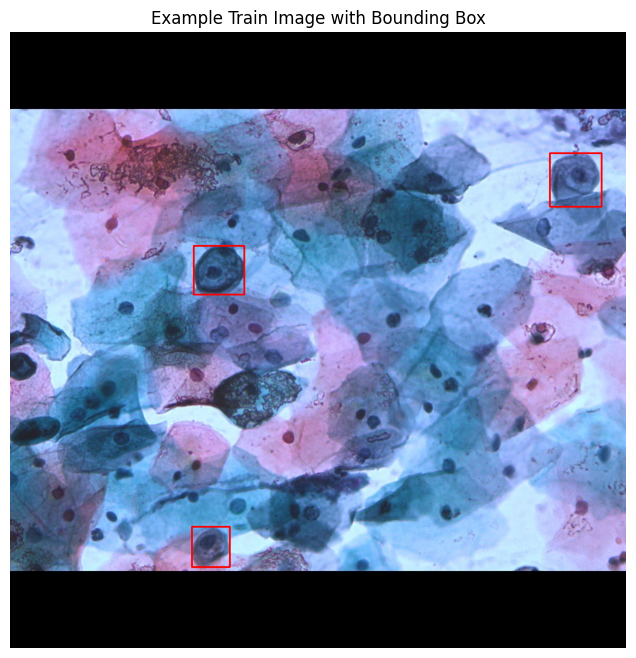


Label content:
2 0.91796875 0.239990234375 0.083984375 0.08642578125
2 0.339111328125 0.38671875 0.08154296875 0.0791015625
2 0.326171875 0.8359375 0.06103515625 0.0654296875



In [19]:
import matplotlib.pyplot as plt

# =========================
# SHOW EXAMPLE FILE
# =========================

example_img_name = random.choice(images)

example_label_name = example_img_name.replace(".jpg", ".txt")

print("\nExample image file:")
print(example_img_name)

print("\nExample label file:")
print(example_label_name)


# =========================
# READ IMAGE
# =========================

img_path = os.path.join(IMG_DIR, example_img_name)
label_path = os.path.join(LABEL_DIR, example_label_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# =========================
# DRAW BBOX
# =========================

with open(label_path) as f:

    for line in f:

        cls, cx, cy, w, h = map(float, line.strip().split())

        x_center = cx * IMG_SIZE
        y_center = cy * IMG_SIZE

        box_w = w * IMG_SIZE
        box_h = h * IMG_SIZE

        x1 = int(x_center - box_w/2)
        y1 = int(y_center - box_h/2)
        x2 = int(x_center + box_w/2)
        y2 = int(y_center + box_h/2)

        cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)


# =========================
# SHOW IMAGE
# =========================

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("Example Train Image with Bounding Box")
plt.axis("off")
plt.show()


# =========================
# SHOW LABEL CONTENT
# =========================

print("\nLabel content:")

with open(label_path) as f:
    print(f.read())

### **Train Detector**

#### Train with Yolov8n (baseline model)

#### Evaluate (baseline model)
* mAP@0.5
* precision
* recall

ใช้ Test set

#### Train with Yolov8s (our model)

#### Evaluate (our model)
* mAP@0.5
* precision
* recall

ใช้ Test set